In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error
from datetime import datetime, timedelta


counters_train = pd.read_csv("counters_train.csv")
events_train = pd.read_csv("events_train.csv")
counters_test = pd.read_csv("counters_test.csv")
events_test = pd.read_csv("events_test.csv")

counters_train["dt"] = pd.to_datetime(counters_train["dt"])
events_train["dt_start"] = pd.to_datetime(events_train["dt_start"])
events_train["dt_end"] = pd.to_datetime(events_train["dt_end"])
counters_test["dt"] = pd.to_datetime(counters_test["dt"])
events_test["dt_start"] = pd.to_datetime(events_test["dt_start"])
events_test["dt_end"] = pd.to_datetime(events_test["dt_end"])

## Задача классификации

Отмечу временные периоды, на которые приходятся события, в таблице с временными данными.

In [32]:
def mark_event(counters, events):
    counters = counters.copy()
    counters["is_event"] = False
    for _, row in events.iterrows():
        mask = (counters["dt"] >= row["dt_start"]) & (counters["dt"] <= row["dt_end"])
        counters.loc[mask, "is_event"] = True
    return counters

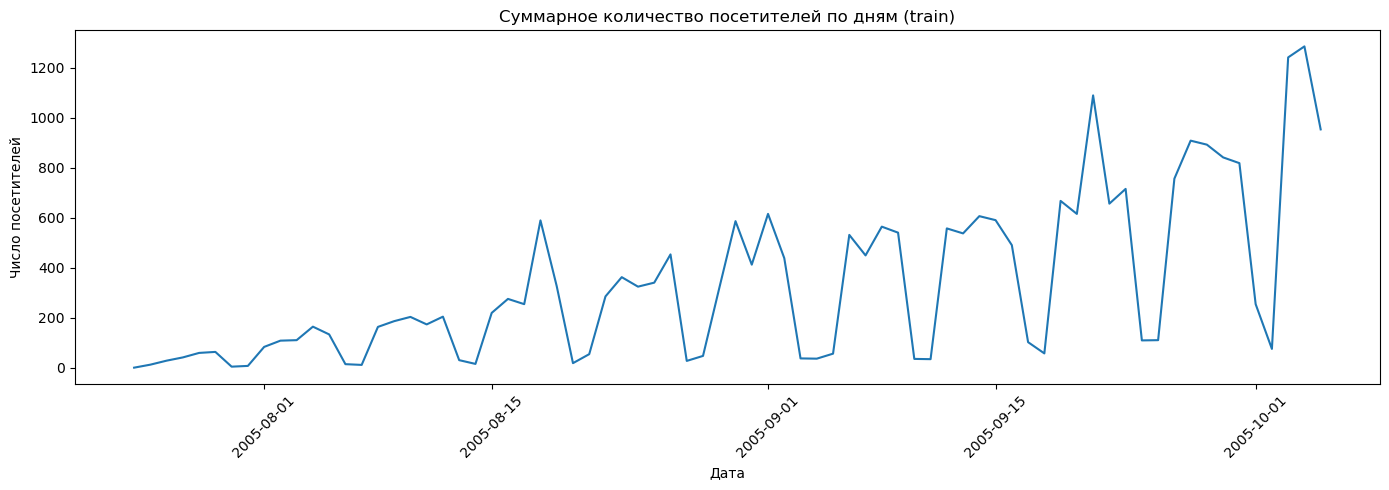

In [33]:
counters_train = mark_event(counters_train, events_train)
counters_test = mark_event(counters_test, events_test)

for df in [counters_train, counters_test]:
    df["hour"] = df["dt"].dt.hour
    df["weekday"] = df["dt"].dt.weekday
    df["weekend"] = df["weekday"] >= 5

plt.figure(figsize=(14, 5))
counters_train.groupby(counters_train["dt"].dt.date)["cnt"].sum().plot()
plt.title("Суммарное количество посетителей по дням (train)")
plt.xlabel("Дата")
plt.ylabel("Число посетителей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

На графике явно заметны повторяющиеся пики и провалы, что может указывать на недельную сезонность — возможно, больше посетителей в выходные или будни, или, возможно, связано с каким-то событием или акцией.




/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_28445/2643884937.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample("H").sum()


<Figure size 1400x1000 with 0 Axes>

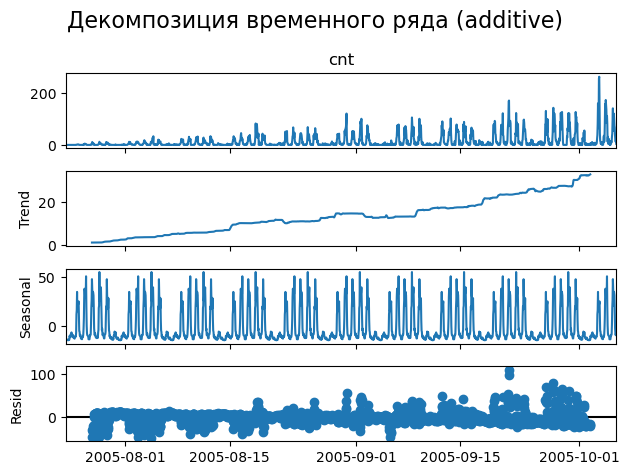

In [49]:
from statsmodels.tsa.seasonal import seasonal_decompose
df = pd.read_csv("counters_train.csv")
df["dt"] = pd.to_datetime(df["dt"])
df.set_index("dt", inplace=True)
df_hourly = df.resample("H").sum()
decomposition = seasonal_decompose(df_hourly["cnt"], model="additive", period=24*7) 

plt.figure(figsize=(14, 10))
decomposition.plot()
plt.suptitle("Декомпозиция временного ряда (additive)", fontsize=16)
plt.tight_layout()
plt.show()



 - Тренд
– С начала периода до конца общая линия движения cnt нестационарна и однозначно возрастает.


 - Сезонность 
– Сильный и стабильный суточный цикл: практически каждый день повторяются характерные пики в одни и те же часы.


 - Остатки 
– В начале периода разброс остатков невелик (±20), но ближе к концу сентября остатки становятся более разбросанными (до ±100), что говорит о росте шумовой составляющей вместе с трендом.
– Наличие отдельных крупных точечных выбросов может указывать на непредсказуемые экстремумы активности, не объясняемые ни трендом, ни сезонностью.


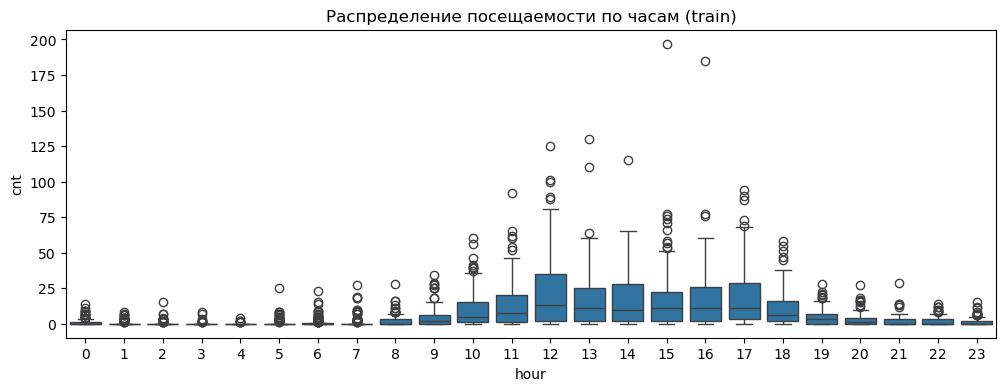

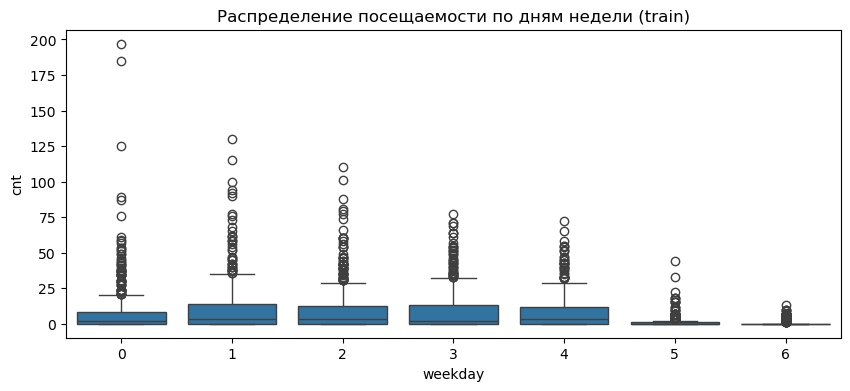

In [34]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=counters_train, x="hour", y="cnt")
plt.title("Распределение посещаемости по часам (train)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=counters_train, x="weekday", y="cnt")
plt.title("Распределение посещаемости по дням недели (train)")
plt.show()


Можно заметитть, что большее число посетителей приходилось на выходные (0-Вс) и время в районе обеда (12-17)

Далее буду рассматривать несколько фичей "cnt", "hour", "weekday", "weekend"

In [35]:
features = ["cnt", "hour", "weekday", "weekend"]
X_clf = counters_train[features]
y_clf = counters_train["is_event"]
X_clf_test = counters_test[features]
y_clf_test = counters_test["is_event"]

Использовать модель RandomForestClassifier

In [36]:
clf_model = RandomForestClassifier(random_state=42)
clf_model.fit(X_clf, y_clf)
preds_clf = clf_model.predict(X_clf_test)

In [37]:
print("Classification Report:\n", classification_report(y_clf_test, preds_clf))
print("Confusion Matrix:\n", confusion_matrix(y_clf_test, preds_clf))

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.95      0.96      1442
        True       0.08      0.15      0.11        46

    accuracy                           0.92      1488
   macro avg       0.53      0.55      0.53      1488
weighted avg       0.94      0.92      0.93      1488

Confusion Matrix:
 [[1363   79]
 [  39    7]]


## Выводы
Модель плохо справляется с выявлением событий, несмотря на высокий accuracy. В данной задаче данная метрика будет не корректна, так как при дисбалансе классов ее не используют, лучше смотреть на precision, recall, f1-score.

Метрики precision, recall, f1-score для класса True — низкие, что указывает на проблему несбалансированности классов.

Macro avg и weighted avg дают более честную оценку. Macro F1-score = 0.53 - результат далек от удовлетворительного.

Можно улучшить модель следующими способами: 
- Применить балансировку классов: oversampling/undersampling
- Использовать вес для классов
- Добавить признаки, которые лучше описывают влияние событий: например, длительность события


## Задача регрессии
Создадим лаги 1, 2, 48, 96  - что соответствует 30 минутам, 1 часу, 1 дню и 2 суткам назад. Такие лаги позволяют модели учитывать как краткосрочные, так и более долгосрочные закономерности.

In [38]:

counters_full = pd.concat([counters_train, counters_test]).sort_values("dt").reset_index(drop=True)
for lag in [1, 2, 48, 96]:
    counters_full[f"cnt_lag_{lag}"] = counters_full["cnt"].shift(lag)

counters_full.dropna(inplace=True)

train_df = counters_full[counters_full["dt"] < "2005-10-06"]
test_df = counters_full[counters_full["dt"] >= "2005-10-06"]

In [39]:
reg_features = ["hour", "weekday", "weekend", "is_event", "cnt_lag_1", "cnt_lag_2", "cnt_lag_48", "cnt_lag_96"]
X_reg = train_df[reg_features]
y_reg = train_df["cnt"]
X_reg_test = test_df[reg_features]
y_reg_test = test_df["cnt"]

reg_model = GradientBoostingRegressor(random_state=42)
reg_model.fit(X_reg, y_reg)

GradientBoostingRegressor(random_state=42)

In [40]:
preds_reg = reg_model.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, preds_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, preds_reg))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 11.51
RMSE: 22.35


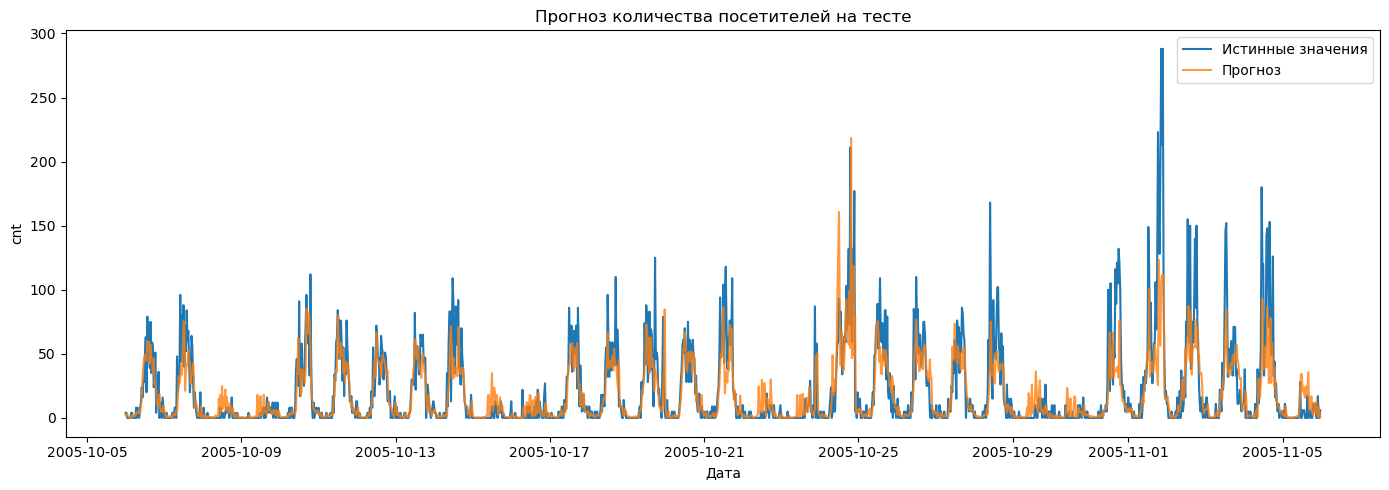

In [41]:
plt.figure(figsize=(14, 5))
plt.plot(test_df["dt"], y_reg_test.values, label="Истинные значения")
plt.plot(test_df["dt"], preds_reg, label="Прогноз", alpha=0.8)
plt.title("Прогноз количества посетителей на тесте")
plt.xlabel("Дата")
plt.ylabel("cnt")
plt.legend()
plt.tight_layout()
plt.show()


 **Выводы по графику:**

В целом, модель корректно улавливает общие пики и спады, которые соответствуют периодам увеличения или уменьшения количества посетителей. Однако, можно заметить, что в некоторых точках (особенно на пиках) прогнозы значительно отклоняются от реальных значений. Это указывает на то, что модель не всегда справляется с точной предсказательной задачей в моменты резких изменений.
Модель хорошо захватывает цикличность и сезонные колебания, что видно по повторяющимся паттернам на графике.
На пиковых значениях (например, 1 ноября 2005 года) модель имеет значительные отклонения от реальных значений. Это может свидетельствовать о сложности модели в предсказании экстремальных значений.
В целом, результат прогноза выглядит довольно хорошим, но присутствуют моменты, когда модель не справляется с точными предсказаниями в моменты резких скачков в данных.

Вывод:
Можно попробовать использовать более сложные модели или дополнительные признаки, которые могут лучше учитывать такие моменты, как резкие изменения в потоке посетителей.
Возможно, ARIMA сделает более точные предсказания в пиковых значениях.


In [42]:
counters_test.describe()

,dt,cnt,hour,weekday
count,1488,1488.000000,1488.000000,1488.000000
mean,2005-10-21 11:44:59.999999872,21.056452,11.500000,3.096774
min,2005-10-06 00:00:00,0.000000,0.000000,0.000000
25%,2005-10-13 17:52:30,0.000000,5.750000,1.000000
50%,2005-10-21 11:45:00,5.000000,11.500000,3.000000
75%,2005-10-29 05:37:30,32.000000,17.250000,5.000000
max,2005-11-05 23:30:00,288.000000,23.000000,6.000000
std,NaN,33.543548,6.924514,1.940969


**Метрики регрессии**

**1. MAE** (MAE устойчива к выбросам)

В среднем модель ошибается на 11-12 посетителей.


**2. RMSE** 

RMSE полезна для оценки, насколько сильно модель ошибается при больших отклонениях от нормы.


Так как среднее значение  cnt 21, то:

  * MAE = 11.51 — 50% относительной ошибки - довольно плохой результат.
  * RMSE = 22.35  - аналогично, плохой результат.


Можно улучшить результат, если

* Добавить больше временных признаков. Например, праздник ли в этот день
* Добавить взаимодействие между признаками. Например, hour × is_event.
* Использовать более мощные модели: XGBoost, LightGBM, CatBoost.
* Попробовать ансамбли моделей или stacking.

